# Konvoluční neuronové sítě



Jaké jsou výhody konvolučních sítí? Zkuste si otevřít [https://playground.tensorflow.org/](https://playground.tensorflow.org/). Jedná se o jednoduchou MLP síť, která se snaží klasifikovat data na vstupu. Pokud vybete nalevo jiný dataset, uvidíte, že klasifikace není možná. Pokud ale vstupem MLP sítě bude nějaký jiný příznak než jen x1 a x2 (např kvadráty), po nějakém době se NN natrénuje na požadovaný výstup. V komplexních datech je to ještě složitější. Nešlo by to ale dělat nějak automaticky? K tomu slouží tzv. konvoluční sítě (a hluboké neuronové sítě - DNN). První takovou síť představil v roce 1997 Yann LeChun (síť LeNet) a tento krok se stal milníkem, který změnil pohled na strojové učení. V tomto cvičení se na takovou NN síť podíváme.

## Práce s neuronovou sítí
Předpokládá se, že jste si prošli řešení první [mlp.ipynb](mlp.ipynb) MLP sítě. V této ukázce zpracujeme síť konvoluční ve variantě LeNet.

V prvním kroce musíme načíst požadované knihovny. Budeme pracovat s knihovnou Tensorflow a rozhraním Keras, které je v nové verzi TF 2.0. Varování týkající se zastaralosti volání funkcí ``numpy`` můžeme ignorovat, jsou způsobeny využitím starší verze TensorFlow 1.14.


In [2]:
import tensorflow.keras as keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
import tensorflow.keras.layers as layers
from tensorflow.keras.optimizers import RMSprop

Knihovny jsou úspěšně načtené. Dalším krokem bude znovu stáhnout dataset MNIST. Tento dataset je rozdělen na trénovací data a testovací data.

In [3]:
# the data, split between train and test sets
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train.shape, x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(60000, 28, 28) (10000, 28, 28)


Nyní se můžeme dát do konstrukce sítě. Deklarujeme si parametry jako jsou počet batchů (dávek) a počet epoch, po které budeme trénovat

In [4]:
batch_size = 128
epochs = 10

Převedeme trénovací data do formátu float čísel 0 - 1. Zde je první **rozdíl vůči MLP síti**. Vstupní obrázky necháme v rozměru 28x28, ale přidáme ještě jednu dimenzi - barevný kanál (v našem případě je jen 1 barva - takže data se prakticky nezmění).

In [5]:
# reshape nedelame, protoze chceme, aby se jednalo o obrazky 28x28 kvuli konvoluci
x_train = x_train.reshape(60000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)
y_test.shape

60000 train samples
10000 test samples


(10000, 10)

Vytvoříme síť konvolučních vrstev následovaných plně propojenými. Každá konvoluce má určeno, jak velký je filtr a kolik těchto filtrů ve výsledku je. Podle nastavení okrajů se buď obrázek zmenší (šířka - velikost filtru + 1) nebo se kraje doplní nulami. Protože jsou výsledné obrázky příznaků (features) moc velké, použije se zmenšení pomocí ```AveragePooling2D``` vrstvy - tato vrstva rozdělí obrázek do čtvrečků 2x2 a vypočítá průměr. Ve svých výpočtech počtu operací tuto operaci ignorujte. V další vrstvě se 6 feature obrázků zase prožene 3x3 filtry. Pozor, na vstupu je 6 kanálů - pro každý filtr a vstupní kanál máme vlastní konvoluční filtr (v druhé vstvě máme tedy 6 * 16 3x3 filtrů), jejichž výstupy se pro všechny kanály sečtou (jak je naznačeno na obrázku)
![schéma konvoluce](https://github.com/mrazekv/bin-lab-nn/blob/main/convolution.gif?raw=1)

Výstup druhého filtru je zase zmenšen. Pomocí Flatten vrstvy dojde k překódování 2D obrázků o 16 kanálech na 1D vektor příznaků (pouhým přeskládáním) a tento vektor je vstupem do závěrečné části, která je tvořena plně propojenými sítěmi.

In [6]:
model1 = Sequential()
model1.add(layers.Input(shape=(28, 28, 1)))
model1.add(layers.Conv2D(filters=6, kernel_size=(3, 3), activation='relu'))
model1.add(layers.AveragePooling2D(pool_size=(2, 2)))

model1.add(layers.Conv2D(filters=16, kernel_size=(3, 3), activation='relu'))
model1.add(layers.AveragePooling2D(pool_size=(2, 2)))

model1.add(layers.Flatten())

model1.add(layers.Dense(units=120, activation='relu'))
model1.add(layers.Dense(units=84, activation='relu'))
model1.add(layers.Dense(units=10, activation = 'softmax'))

model2 = Sequential()
model2.add(layers.Input(shape=(28, 28, 1)))
model2.add(layers.Conv2D(filters=6, kernel_size=(3, 3), activation='relu'))
model2.add(layers.AveragePooling2D(pool_size=(2, 2)))

model2.add(layers.Conv2D(filters=16, kernel_size=(3, 3), activation='relu'))
model2.add(layers.AveragePooling2D(pool_size=(2, 2)))

model2.add(layers.Flatten())

model2.add(layers.Dense(units=120, activation='relu'))
model2.add(layers.Dense(units=10, activation = 'softmax'))

model3 = Sequential()
model3.add(layers.Input(shape=(28, 28, 1)))
model3.add(layers.Conv2D(filters=6, kernel_size=(3, 3), activation='relu'))
model3.add(layers.AveragePooling2D(pool_size=(2, 2)))

model3.add(layers.Flatten())

model3.add(layers.Dense(units=120, activation='relu'))
model3.add(layers.Dense(units=84, activation='relu'))
model3.add(layers.Dense(units=10, activation = 'softmax'))

model4 = Sequential()
model4.add(layers.Input(shape=(28, 28, 1)))
model4.add(layers.Conv2D(filters=6, kernel_size=(3, 3), activation='relu'))
model4.add(layers.AveragePooling2D(pool_size=(2, 2)))

model4.add(layers.Flatten())

model4.add(layers.Dense(units=120, activation='relu'))
model4.add(layers.Dense(units=10, activation = 'softmax'))

model1.summary()
model2.summary()
model3.summary()
model4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 6)      │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 13, 13, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 16)     │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,074 (234.66 KB)

 Trainable params: 60,074 (234.66 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 26, 26, 6)      │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_5             │ (None, 13, 13, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1014)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 120)            │       121,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,070 (480.74 KB)

 Trainable params: 123,070 (480.74 KB)

 Non-trainable params: 0 (0.00 B)

Nyní můžeme model zkompilovat a spustit trénování. Tato operace může zabrat nějaký čas, zejména pokud nemáte GPU.

In [7]:
model1.compile(loss='categorical_crossentropy',
              optimizer=RMSprop(),
              metrics=['accuracy'])

history = model1.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_test, y_test))

model2.compile(loss='categorical_crossentropy',
              optimizer=RMSprop(),
              metrics=['accuracy'])

history = model2.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_test, y_test))

model3.compile(loss='categorical_crossentropy',
              optimizer=RMSprop(),
              metrics=['accuracy'])

history = model3.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_test, y_test))

model4.compile(loss='categorical_crossentropy',
              optimizer=RMSprop(),
              metrics=['accuracy'])

history = model4.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_test, y_test))


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8741 - loss: 0.4227 - val_accuracy: 0.9565 - val_loss: 0.1451
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9643 - loss: 0.1198 - val_accuracy: 0.9614 - val_loss: 0.1178
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9757 - loss: 0.0786 - val_accuracy: 0.9745 - val_loss: 0.0774
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9809 - loss: 0.0604 - val_accuracy: 0.9837 - val_loss: 0.0495
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9851 - loss: 0.0490 - val_accuracy: 0.9867 - val_loss: 0.0396
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9872 - loss: 0.0415 - val_accuracy: 0.9865 - val_loss: 0.0419
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9886 - loss: 0.0349 - val_accuracy: 0.9845 - val_loss: 0.0473
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9906 - loss: 0.0311 - val_accuracy: 0

Model je nyní natrénovaný (na poměrně malý počet epoch). Nyní jej můžeme uložit nebo použít na jednom konkrétním obrázku

In [8]:
score = model1.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

score = model2.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

score = model3.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

score = model4.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.035857196897268295
Test accuracy: 0.9884999990463257
Test loss: 0.032603178173303604
Test accuracy: 0.9894999861717224
Test loss: 0.04456299915909767
Test accuracy: 0.9871000051498413
Test loss: 0.04989909008145332
Test accuracy: 0.9848999977111816


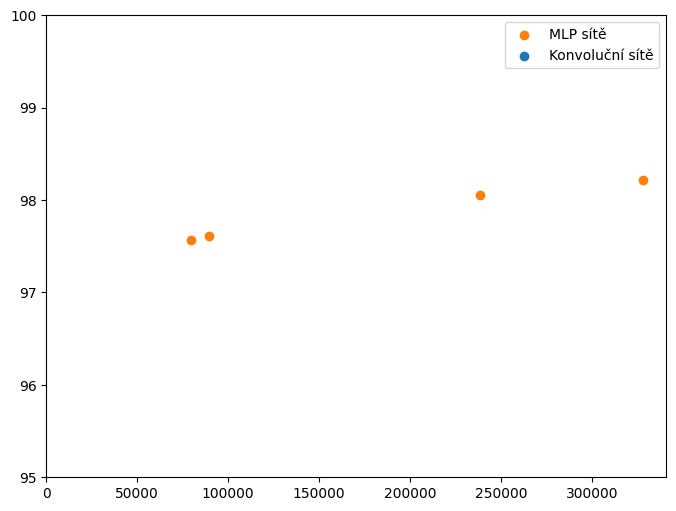

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# Data ve formatu prikon / pocet_nasobeni
# TODO: upravte dle vlastniho uvazeni
df = pd.DataFrame([
  {"type" : "mlp", "accuracy": 98.05, "MAC": 238200},
  {"type" : "mlp", "accuracy": 97.57, "MAC": 79400},
  {"type" : "mlp", "accuracy": 97.61, "MAC": 89400},
  {"type" : "mlp", "accuracy": 98.22, "MAC": 328200},
])

fig, ax = plt.subplots(figsize=(8, 6))

for nn_type, label, color in [("mlp", "MLP sítě", "tab:orange"), ("conv", "Konvoluční sítě", "tab:blue")]:
  df_tmp = df.query("type == @nn_type")
  ax.scatter(df_tmp["MAC"], df_tmp["accuracy"], color=color, label=label)

ax.set(
    xlim=(0, None),
    ylim=(95, 100)
    # todo
)
ax.legend()
fig.show()